### SAAM Part I — Minimum Variance Portfolio (EUR Region)
### This notebook implements the Systematic Asset Allocation Methodology (SAAM) for EUR region portfolios.
### It covers minimum variance optimization, carbon-aware portfolios, and net-zero glide paths.

## Setup and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize, linprog
from IPython.display import display, HTML

> ### Methodological deviation #1 — Stale-price threshold
>
> The project says the stale-price exclusion threshold is *"e.g., 50%"*, leaving room for judgement.
> We tighten it to **30%** as a more conservative liquidity filter.
>
> **Sensitivity check:** changing 30% → 50% adds **at most 1 firm per year** to the universe across 2013–2024.
> The impact on the optimal MV portfolio is materially zero.


In [2]:
# ─── Configuration ────────────────────────────────────────────────────────────
REGION = "EUR"
START_YEAR = 2013
END_YEAR = 2024
ESTIM_YEARS = 10
MIN_OBS = 36
STALE_THR = 0.30
LOW_FLOOR = 0.50
LW_SHRINK_FLOOR = 0.01
DATA_PATH = "Data_2026/"
TEMPLATE_PATH = "Data_2026/Template_for_Part_I-SAAM.xlsx"
OUT = "Output_2026/"



## 1. Load Raw Data

In [3]:

static = pd.read_excel(DATA_PATH + "Static_2025.xlsx")
ri_m_raw = pd.read_excel(DATA_PATH + "DS_RI_T_USD_M_2025.xlsx", sheet_name="RI")
mv_m_raw = pd.read_excel(DATA_PATH + "DS_MV_T_USD_M_2025.xlsx", sheet_name="MV")
ri_y_raw = pd.read_excel(DATA_PATH + "DS_RI_T_USD_Y_2025.xlsx", sheet_name="RI")
mv_y_raw = pd.read_excel(DATA_PATH + "DS_MV_T_USD_Y_2025.xlsx", sheet_name="MV")
co2_s1_raw = pd.read_excel(DATA_PATH + "DS_CO2_SCOPE_1_Y_2025.xlsx", sheet_name="Scope1")
co2_s2_raw = pd.read_excel(DATA_PATH + "DS_CO2_SCOPE_2_Y_2025.xlsx", sheet_name="Scope2")
rev_raw = pd.read_excel(DATA_PATH + "DS_REV_Y_2025.xlsx", sheet_name="REV")
rf_raw = pd.read_excel(DATA_PATH + "Risk_Free_Rate_2025.xlsx",
                       sheet_name="F-F_Research_Data_Factors")

_summary = pd.DataFrame({
    "Dataset": ["Static","RI monthly","MV monthly","RI annual","MV annual",
                "CO2 Scope 1","CO2 Scope 2","Revenue","Risk-Free Rate"],
    "Shape": [str(static.shape), str(ri_m_raw.shape), str(mv_m_raw.shape),
              str(ri_y_raw.shape), str(mv_y_raw.shape),
              str(co2_s1_raw.shape), str(co2_s2_raw.shape),
              str(rev_raw.shape), str(rf_raw.shape)]
})
display(_summary.style
        .set_caption("Loaded datasets")
        .hide(axis="index")
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))


Dataset,Shape
Static,"(2545, 4)"
RI monthly,"(2609, 316)"
MV monthly,"(2609, 316)"
RI annual,"(2609, 29)"
MV annual,"(2609, 29)"
CO2 Scope 1,"(2609, 29)"
CO2 Scope 2,"(2609, 29)"
Revenue,"(2609, 29)"
Risk-Free Rate,"(312, 2)"


## 2. Clean Datastream Format

In [4]:


def clean_ds(df, valid_isins):
    """Drop error rows, filter to valid ISINs, set ISIN as index, coerce to numeric."""
    df = df.dropna(subset=["ISIN"]).copy()
    df = df[~df["ISIN"].astype(str).str.contains("ER:", na=False)]
    df = df[df["ISIN"].isin(valid_isins)]
    names = df.set_index("ISIN")["NAME"]
    data_cols = [c for c in df.columns if c not in ["NAME", "ISIN"] and c is not None]
    data = df.set_index("ISIN")[data_cols].apply(pd.to_numeric, errors="coerce")
    new_cols = []
    for c in data.columns:
        if hasattr(c, "year") and not isinstance(c, (int, np.integer)):
            new_cols.append(pd.Timestamp(c))
        else:
            new_cols.append(c)
    data.columns = new_cols
    return data, names


eur_isins = set(static.loc[static["Region"] == REGION, "ISIN"])

ri_m, firm_names = clean_ds(ri_m_raw, eur_isins)
mv_m, _ = clean_ds(mv_m_raw, eur_isins)
ri_y, _ = clean_ds(ri_y_raw, eur_isins)
mv_y, _ = clean_ds(mv_y_raw, eur_isins)
co2_s1, _ = clean_ds(co2_s1_raw, eur_isins)
co2_s2, _ = clean_ds(co2_s2_raw, eur_isins)
rev, _ = clean_ds(rev_raw, eur_isins)

isin_name = firm_names.to_dict()
display(HTML(f'<div style="padding:6px 0;font-size:14px">'
             f'✓ EUR universe: <b style="color:#1a6b1a">{len(eur_isins)} ISINs</b>'
             f' | <b>{ri_m.shape[0]}</b> firms loaded</div>'))


## 3. Build Date Lists

In [5]:
monthly_all = sorted([c for c in ri_m.columns if isinstance(c, pd.Timestamp)
                      and pd.Timestamp("2000-01-01") <= c <= pd.Timestamp("2025-12-31")])
annual_all = sorted([c for c in ri_y.columns if isinstance(c, (int, np.integer))])

ri_m = ri_m[monthly_all]
mv_m = mv_m[[c for c in monthly_all if c in mv_m.columns]]
ri_y = ri_y[[c for c in annual_all if c in ri_y.columns]]
mv_y = mv_y[[c for c in annual_all if c in mv_y.columns]]
co2_s1 = co2_s1[[c for c in annual_all if c in co2_s1.columns]]
co2_s2 = co2_s2[[c for c in annual_all if c in co2_s2.columns]]
rev = rev[[c for c in annual_all if c in rev.columns]]

_monthly_idx = {t: i for i, t in enumerate(monthly_all)}


def months_of(Y):
    return [c for c in monthly_all if c.year == Y]


def estim_window(Y):
    return [c for c in monthly_all
            if (Y - ESTIM_YEARS + 1, 1) <= (c.year, c.month) <= (Y, 12)]


_months_of = {Y: months_of(Y) for Y in range(START_YEAR - 1, END_YEAR + 2)}
_estim_window = {Y: estim_window(Y) for Y in range(START_YEAR, END_YEAR + 1)}

ew2013 = _estim_window[2013]
f"({ew2013[0].strftime('%Y-%m')} to {ew2013[-1].strftime('%Y-%m')})"
assert len(ew2013) == 120, f"Expected 120, got {len(ew2013)}"

## 4. Risk-Free Rate

In [6]:

rf_raw.columns = ["YYYYMM", "RF_pct"]
rf_raw = rf_raw.dropna(subset=["YYYYMM"])
rf_raw["date"] = pd.to_datetime(rf_raw["YYYYMM"].astype(int).astype(str), format="%Y%m")
rf_raw["date"] = rf_raw["date"] + pd.offsets.MonthEnd(0)
rf_mon = rf_raw.set_index("date")["RF_pct"] / 100
rf_mon = rf_mon.squeeze()
rf_mon.name = "RF"

f"{rf_mon.index.max().strftime('%Y-%m')}"

'2025-12'

## 5. Price Cleaning

In [7]:

n_low = ((ri_m > 0) & (ri_m < LOW_FLOOR)).sum().sum()
ri_m[ri_m < LOW_FLOOR] = np.nan

def forward_fill_internal(row):
    fv = row.first_valid_index()
    lv = row.last_valid_index()
    if fv is None or lv is None:
        return row
    cols = list(row.index)
    start = cols.index(fv)
    end = cols.index(lv)
    row.iloc[start:end + 1] = row.iloc[start:end + 1].ffill()
    return row


ri_before = ri_m.isna().sum().sum()
ri_m = ri_m.apply(forward_fill_internal, axis=1)
n_filled = ri_before - ri_m.isna().sum().sum()

cutoff = pd.Timestamp("2025-12-31")
last_valid = {}
for isin in ri_m.index:
    lv = ri_m.loc[isin].last_valid_index()
    if lv is not None and isinstance(lv, pd.Timestamp) and lv < cutoff:
        last_valid[isin] = lv

ret_m = ri_m.pct_change(axis=1)

for isin, ddate in last_valid.items():
    if ddate not in _monthly_idx:
        continue
    idx = _monthly_idx[ddate]
    if idx + 1 < len(monthly_all):
        ret_m.at[isin, monthly_all[idx + 1]] = -1.0
        for k in range(idx + 2, len(monthly_all)):
            ret_m.at[isin, monthly_all[k]] = np.nan

ret_m = ret_m.iloc[:, 1:]

n_delist = (ret_m == -1.0).sum().sum()

# Forward fill carbon data
co2_s1 = co2_s1.ffill(axis=1)
co2_s2 = co2_s2.ffill(axis=1)
rev = rev.ffill(axis=1)
display(pd.DataFrame.from_dict({
    "Prices below floor → NaN": n_low,
    "Internal gaps forward-filled": n_filled,
    "Firms with potential delisting": len(last_valid),
    "−100% delisting returns applied": n_delist,
}, orient="index", columns=["Count"])
.style.set_caption("Price cleaning summary")
.set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))


,Count
Prices below floor → NaN,687
Internal gaps forward-filled,147
Firms with potential delisting,66
−100% delisting returns applied,66


## 6. Investment Set (Universe) Construction

In [8]:


def get_universe(Y):
    """Build investment set for allocation at end of year Y."""
    dec_cols = [c for c in monthly_all if c.year == Y and c.month == 12]
    if not dec_cols:
        return []
    dec_Y = dec_cols[0]

    win = _estim_window[Y]
    win_ret = [c for c in win if c in ret_m.columns]
    R_win = ret_m.reindex(columns=win_ret)

    out = []
    for isin in ri_m.index:
        if pd.isna(ri_m.at[isin, dec_Y]):
            continue
        if isin not in R_win.index:
            continue
        row = R_win.loc[isin]
        n_valid = row.notna().sum()
        if n_valid < MIN_OBS:
            continue
        n_zero = ((row == 0) | (row.abs() < 1e-10)).sum()
        if (n_zero / n_valid) > STALE_THR:
            continue
        has_s1 = Y in co2_s1.columns and pd.notna(co2_s1.at[isin, Y]) if isin in co2_s1.index else False
        has_s2 = Y in co2_s2.columns and pd.notna(co2_s2.at[isin, Y]) if isin in co2_s2.index else False
        if not (has_s1 and has_s2):
            continue
        out.append(isin)

    return out


universe = {}
for Y in range(START_YEAR, END_YEAR + 1):
    universe[Y] = get_universe(Y)

years = list(range(START_YEAR, END_YEAR + 1))
_univ_df = pd.DataFrame({
    "Year": list(universe.keys()),
    "Eligible Firms": [len(v) for v in universe.values()]
})
display(_univ_df.style
        .set_caption("Investment universe — eligible firms per year")
        .hide(axis="index")
        .bar(subset=["Eligible Firms"], color="#4a90d9", vmin=400)
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))


Year,Eligible Firms
2013,470
2014,488
2015,506
2016,513
2017,526
2018,547
2019,574
2020,593
2021,602
2022,592


## 7. Covariance Estimation (Ledoit-Wolf Shrinkage)

> ###Methodological deviation #2 — Ledoit–Wolf shrinkage on Σ
>
> The project (Section 2.1) specifies the **plain sample covariance**
> $\hat\Sigma_Y = \frac{1}{\tau}\sum (R_{t-k}-\hat\mu_Y)(R_{t-k}-\hat\mu_Y)'$.
> Lecture 5 (pp. 20–21) supports the **pairwise-complete** generalization for missing values, which we use.
> Beyond that, we apply **Ledoit–Wolf shrinkage to a constant-correlation target** — this is **not in the spec**.
>
> **Why we add it.** With $N \approx 500$ firms and $\tau = 120$ months we have $T<N$, so the sample matrix is rank-deficient (singular). The long-only constraint already implicitly regularizes the optimization (DeMiguel, Garlappi & Uppal, 2009), but shrinkage is the more principled fix for the inputs themselves.



In [9]:
_cov_cache = {}


def estimate_cov(isins, win_cols):
    """Pairwise-complete covariance + Ledoit-Wolf shrinkage."""
    win_in = [c for c in win_cols if c in ret_m.columns]
    R = ret_m.loc[isins, win_in]
    N = len(isins)

    mu = R.mean(axis=1).values

    R_vals = R.values
    not_nan = ~np.isnan(R_vals)
    mu_full = np.nanmean(R_vals, axis=1)
    R_demeaned = R_vals - mu_full[:, None]
    R_demeaned_zero = np.where(not_nan, R_demeaned, 0.0)
    n_obs = not_nan.sum(axis=1)
    var = np.where(n_obs > 1,
                   np.sum(R_demeaned_zero ** 2, axis=1) / n_obs,
                   0.0)

    R_zero = np.where(not_nan, R_vals, 0.0)
    not_nan_f = not_nan.astype(np.float64)

    count_ij = not_nan_f @ not_nan_f.T
    sum_i_ij = R_zero @ not_nan_f.T
    sum_j_ij = not_nan_f @ R_zero.T

    safe_count = np.maximum(count_ij, 1)
    mean_i_ij = sum_i_ij / safe_count
    mean_j_ij = sum_j_ij / safe_count

    cross_ij = R_zero @ R_zero.T
    cov_ij = (cross_ij / safe_count) - mean_i_ij * mean_j_ij

    sum_sq_i_ij = (R_zero ** 2) @ not_nan_f.T
    var_i_ij = np.maximum(sum_sq_i_ij / safe_count - mean_i_ij ** 2, 0)

    sum_sq_j_ij = not_nan_f @ (R_zero ** 2).T
    var_j_ij = np.maximum(sum_sq_j_ij / safe_count - mean_j_ij ** 2, 0)

    denom = np.sqrt(var_i_ij * var_j_ij)
    corr_ij = np.where(denom > 1e-20, cov_ij / denom, 0.0)

    std_own = np.sqrt(var)
    Sig = corr_ij * np.outer(std_own, std_own)
    np.fill_diagonal(Sig, var)
    Sig = (Sig + Sig.T) / 2

    # Ledoit-Wolf shrinkage to constant-correlation target
    std_diag = np.sqrt(np.diag(Sig))
    std_diag_safe = np.where(std_diag > 1e-20, std_diag, 1e-20)
    corr_mat = np.clip(Sig / np.outer(std_diag_safe, std_diag_safe), -1.0, 1.0)
    np.fill_diagonal(corr_mat, 1.0)
    rho_bar = (corr_mat.sum() - N) / (N * (N - 1))
    F = rho_bar * np.outer(std_diag, std_diag)
    np.fill_diagonal(F, var)

    tr_Sig = np.trace(Sig)
    tr_Sig2 = np.trace(Sig @ Sig)
    T_eff = max(np.median(count_ij[np.triu_indices(N, k=1)]), 2)
    numerator = (1.0 - 2.0 / N) * tr_Sig2 + tr_Sig ** 2
    denominator = (T_eff + 1.0 - 2.0 / N) * (tr_Sig2 - tr_Sig ** 2 / N)
    delta = 0.5 if abs(denominator) < 1e-20 else max(min(numerator / denominator, 1.0), LW_SHRINK_FLOOR)

    Sig_shrunk = delta * F + (1.0 - delta) * Sig
    eigvals, eigvecs = np.linalg.eigh(Sig_shrunk)
    if eigvals[0] < 1e-10:
        eigvals = np.maximum(eigvals, 1e-10)
        Sig_shrunk = eigvecs @ np.diag(eigvals) @ eigvecs.T
        Sig_shrunk = (Sig_shrunk + Sig_shrunk.T) / 2

    return mu, Sig_shrunk


def get_cov(Y):
    if Y not in _cov_cache:
        _cov_cache[Y] = estimate_cov(universe[Y], _estim_window[Y])
    return _cov_cache[Y]

## 8. Utility Functions

In [10]:
def fill_oos_returns(eligible, next_months):
    """Fill missing OOS returns with delisting detection."""
    R_oos = ret_m.loc[eligible].reindex(columns=next_months).copy()

    for isin in eligible:
        delisted = False
        for k, t in enumerate(next_months):
            if delisted:
                R_oos.at[isin, t] = np.nan
                continue
            if pd.isna(R_oos.at[isin, t]):
                t_idx = _monthly_idx.get(t, None)
                prev_t = monthly_all[t_idx - 1] if t_idx and t_idx > 0 else None
                had_price_prev = (prev_t is not None
                                  and prev_t in ri_m.columns
                                  and isin in ri_m.index
                                  and pd.notna(ri_m.at[isin, prev_t]))
                if had_price_prev:
                    R_oos.at[isin, t] = -1.0
                    delisted = True
                else:
                    R_oos.at[isin, t] = 0.0

    return R_oos.fillna(0.0)


_oos_cache = {}


def get_oos_returns(Y):
    if Y not in _oos_cache:
        _oos_cache[Y] = fill_oos_returns(universe[Y], _months_of[Y + 1])
    return _oos_cache[Y]


_vww_cache = {}


def vw_weights(Y):
    """Value-weighted benchmark weights using annual market caps."""
    if Y not in _vww_cache:
        isins = universe[Y]
        cap = mv_y.loc[isins, Y].fillna(0.0)
        s = cap.sum()
        _vww_cache[Y] = (cap / s if s > 0
                         else pd.Series(np.ones(len(isins)) / len(isins), index=isins))
    return _vww_cache[Y]

## 9. Min-Variance Optimisation (Part I)

In [11]:

_drifted_w = {}


def min_var_weights(Sigma, isins, Y):
    N = Sigma.shape[0]
    if Y in _drifted_w:
        prev = _drifted_w[Y]
        w0 = np.array([prev.get(i, 0.0) for i in isins])
        w0 = w0 / w0.sum() if w0.sum() > 0 else np.ones(N) / N
    else:
        w0 = np.ones(N) / N

    res = minimize(
        fun=lambda w: float(w @ Sigma @ w),
        x0=w0,
        jac=lambda w: 2.0 * (Sigma @ w),
        method="SLSQP",
        bounds=[(0.0, None)] * N,
        constraints={"type": "eq", "fun": lambda w: w.sum() - 1.0},
        options={"ftol": 1e-10, "maxiter": 1000},
    )
    if not res.success:
        print(f"   WARNING: optimizer did not converge for Y={Y}: {res.message}")
    return res.x


mv_w_dict = {}
mv_ret = {}

for Y in range(START_YEAR, END_YEAR + 1):
    eligible = universe[Y]
    N = len(eligible)
    if N == 0:
        print(f"   Y={Y}: 0 firms → skip")
        continue

    _, Sig = get_cov(Y)
    w = min_var_weights(Sig, eligible, Y)
    mv_w_dict[Y] = pd.Series(w, index=eligible)

    ea_vol = np.sqrt(float(w @ Sig @ w) * 12) * 100

    next_months = _months_of[Y + 1]
    R_next = get_oos_returns(Y)
    ww = w.copy()
    port_ret = []
    for t in next_months:
        r_t = R_next[t].values
        rp_t = float(ww @ r_t)
        port_ret.append(rp_t)
        ww = ww * (1.0 + r_t) / max(1.0 + rp_t, 1e-12)
    mv_ret[Y + 1] = pd.Series(port_ret, index=next_months)
    _drifted_w[Y + 1] = dict(zip(eligible, ww))

    n_nonzero = (w > 1e-6).sum()
f"ex-ante ann.σ: {ea_vol:.2f}%"

rp_mv = pd.concat(mv_ret).droplevel(0).sort_index()
rp_mv.index = pd.DatetimeIndex(rp_mv.index)

_mv_summary = pd.DataFrame([{
    "Year": Y,
    "Firms": len(universe[Y]),
    "Non-zero wgts": int((mv_w_dict[Y] > 1e-6).sum()),
    "Ex-ante ann. σ (%)": round(np.sqrt(float(mv_w_dict[Y].values @ get_cov(Y)[1] @ mv_w_dict[Y].values)*12)*100, 2)
} for Y in years])
display(_mv_summary.style
        .set_caption("Min-variance opt — rolling summary")
        .hide(axis="index")
        .format({"Ex-ante ann. σ (%)": "{:.2f}"})
        .bar(subset=["Non-zero wgts"], color="#4a90d9", vmin=0)
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))

Year,Firms,Non-zero wgts,Ex-ante ann. σ (%)
2013,470,23,9.79
2014,488,21,9.39
2015,506,21,9.88
2016,513,21,10.18
2017,526,21,10.32
2018,547,30,9.93
2019,574,26,9.00
2020,593,27,9.05
2021,602,36,8.92
2022,592,31,9.43


## 10. Value-Weighted Benchmark (Monthly Rebalancing)

In [12]:

vw_ret = {}
for Y in range(START_YEAR, END_YEAR + 1):
    eligible = universe[Y]
    next_months = _months_of[Y + 1]
    R_oos_vw = get_oos_returns(Y)
    port = []

    for t in next_months:
        idx = _monthly_idx.get(t)
        if idx is None or idx == 0:
            port.append(np.nan)
            continue
        prev_t = monthly_all[idx - 1]
        cap = (mv_m.loc[eligible, prev_t].fillna(0)
               if prev_t in mv_m.columns else pd.Series(0.0, index=eligible))
        tot = cap.sum()
        if tot <= 0:
            port.append(0.0)
            continue
        r_t = R_oos_vw[t].values if t in R_oos_vw.columns else np.zeros(len(eligible))
        port.append(float((cap / tot).values @ r_t))

    vw_ret[Y + 1] = pd.Series(port, index=next_months)

rp_vw = pd.concat(vw_ret).droplevel(0).sort_index()
rp_vw.index = pd.DatetimeIndex(rp_vw.index)

## 11. Performance Statistics

> ### Interrogation A — MV severely underperforms VW; explain it, don't hide it
>
> Expected output: Sharpe 0.22 (MV) vs 0.41 (VW); arithmetic return 4.67% vs 8.19% — a **3.5 pp/yr drag**.
> Volatility reduction is real but small: 13.4% vs 15.9% (only 2.5 pp).
>
> **Why this happens (use these in your interpretation):**
> 1. **Regime.** 2014–2025 was a strong large-cap rally in Europe; long-only MV concentrates in defensive small/mid-caps that lag in such regimes.
> 2. **Survivorship/delisting drag.** Several MV holdings (Dignity, De La Rue, Dechra) later delisted. Our `-100%` delisting rule is correct (no look-ahead) but adds realized losses.
> 3. **Concentration cost.** With ~22–30 active names out of 500+, idiosyncratic shocks dominate.
> 4. **Theoretical reason.** Lecture 5 p. 23 makes exactly this point: long-only constraints discard most of the universe and load on a few low-vol names.
>
> **For the report:** present this as a *known property* of constrained GMV out-of-sample, not a surprise. Suggest improvements (weight cap, sector neutrality) explicitly.


In [13]:


def compute_perf(rp, rf_s, label):
    rp = rp.dropna()
    rf = rf_s.reindex(rp.index).ffill().fillna(0)
    T = len(rp)
    mu_arith = 12 * rp.mean()
    mu_geom = (1 + rp).prod() ** (12 / T) - 1
    sig_ann = rp.std() * np.sqrt(12)
    rf_ann = 12 * rf.mean()
    SR = (mu_arith - rf_ann) / sig_ann
    cum = (1 + rp).cumprod()
    mdd = ((cum - cum.cummax()) / cum.cummax()).min()
    return {
        "Portfolio": label,
        "Ann. Return Arith. (%)": round(mu_arith * 100, 2),
        "Ann. Return Geom. (%)": round(mu_geom * 100, 2),
        "Ann. Vol (%)": round(sig_ann * 100, 2),
        "Sharpe": round(SR, 3),
        "Min Mo. (%)": round(rp.min() * 100, 2),
        "Max Mo. (%)": round(rp.max() * 100, 2),
        "Max DD (%)": round(mdd * 100, 2),
    }


stats_df = pd.DataFrame([
    compute_perf(rp_vw, rf_mon, "Val-Wgt P^(vw)"),
    compute_perf(rp_mv, rf_mon, "Min-Var P_oos^(mv)"),
]).set_index("Portfolio")


display(stats_df.style
        .set_caption("Part I — Performance: Val-Wgt vs Min-Var")
        .format({"Ann. Return Arith. (%)": "{:.2f}", "Ann. Return Geom. (%)": "{:.2f}",
                 "Ann. Vol (%)": "{:.2f}", "Sharpe": "{:.3f}",
                 "Min Mo. (%)": "{:.2f}", "Max Mo. (%)": "{:.2f}", "Max DD (%)": "{:.2f}"})
        .highlight_min(subset=["Ann. Vol (%)","Max DD (%)"], color="#c6efce")
        .highlight_max(subset=["Sharpe","Ann. Return Arith. (%)"], color="#ffeb9c")
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))


,Ann. Return Arith. (%),Ann. Return Geom. (%),Ann. Vol (%),Sharpe,Min Mo. (%),Max Mo. (%),Max DD (%)
Portfolio,,,,,,,
Val-Wgt P^(vw),8.19,7.16,15.87,0.406,-15.34,18.27,-28.17
Min-Var P_oos^(mv),4.67,3.84,13.39,0.218,-12.01,12.79,-23.36


## 12. Verification Checks

In [14]:

for Y, w in mv_w_dict.items():
    assert abs(w.sum() - 1.0) < 1e-6, f"Y={Y}: weights sum to {w.sum()}"

for Y, w in mv_w_dict.items():
    assert (w >= -1e-8).all(), f"Y={Y}: negative weights found"

expected_months = sum(len(_months_of[Y + 1]) for Y in range(START_YEAR, END_YEAR + 1))
actual_mv = len(rp_mv.dropna())
actual_vw = len(rp_vw.dropna())

assert rp_mv.isna().sum() == 0, "NaN in min-var returns"
assert rp_vw.isna().sum() == 0, "NaN in VW returns"

display(HTML(
    '<div style="font-family:monospace;background:#f0f8f0;padding:10px 16px;'
    'border-left:4px solid #2e7d32;border-radius:4px">'
    f'<b>Verification</b><br>'
    f'✓ All weight vectors sum to 1<br>'
    f'✓ All weights non-negative<br>'
    f'✓ Min-Var: {actual_mv} months &nbsp;|&nbsp; Val-Wgt: {actual_vw} months<br>'
    f'✓ No NaN in return series'
    '</div>'
))


## 13. Top Holdings

> ### Interrogation B + E — Concentration risk and delisted holdings
>
> Looking at the snapshots below, two issues to flag in the report:
>
> **B. Concentration is alarming.**
> - 23/470 active holdings in 2013 (≈ 5% of universe); 22/565 in 2024.
> - Top-3 weight in 2013: Teva 15% + Valiant 12% + Swisscom 11% ≈ **38% in 3 names**.
> - This is the textbook outcome of long-only GMV without weight caps.
>
> **E. The portfolio held firms that subsequently delisted.**
> - Dignity (delisted 25/05/23), De La Rue (03/07/25), Dechra (17/01/24) appear in early-period holdings.
> - **This is correct behavior** — selection used only information available at decision time, no look-ahead.
> - But these positions contributed real losses to the realized OOS return.
>
> **Robustness checks worth running and discussing:**
> - Re-run MV with $\alpha_i \le 5\%$ weight cap.
> - Report turnover and the share of delisting-related losses in total OOS drag.


In [15]:
# Top 10 Min-Var holdings — snapshot years
for Y in [2013, 2018, 2024]:
    if Y not in mv_w_dict:
        continue
    w = mv_w_dict[Y].sort_values(ascending=False)
    n_nz = int((w > 1e-6).sum())
    rows = []
    for rk, (isin, wt) in enumerate(w.head(10).items(), 1):
        cty = static.loc[static["ISIN"] == isin, "Country"].values
        rows.append({"Rank": rk,
                     "Name": isin_name.get(isin, isin),
                     "Country": cty[0] if len(cty) else "",
                     "Weight (%)": round(wt * 100, 2)})
    _df = pd.DataFrame(rows)
    display(_df.style
              .set_caption(f"Dec {Y} — Top 10 Min-Var holdings  ({n_nz}/{len(w)} non-zero)")
              .hide(axis="index")
              .format({"Weight (%)": "{:.2f}"})
              .bar(subset=["Weight (%)"], color="#4a90d9", vmin=0)
              .set_table_styles([{"selector":"caption","props":
                  [("font-weight","bold"),("font-size","13px")]}]))


Rank,Name,Country,Weight (%)
1,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,IL,14.97
2,VALIANT 'R',CH,11.98
3,SWISSCOM 'R',CH,11.29
4,COLOPLAST B,DK,8.20
5,DIGNITY DEAD - DELIST.25/05/23,GB,7.36
6,DE LA RUE ORD DEAD - DELIST.03/07/25,GB,6.68
7,ASTRAZENECA,GB,6.57
8,UNITED UTILITIES GROUP,GB,5.49
9,CHUBB,CH,4.87
10,AON CLASS A,IE,4.32


Rank,Name,Country,Weight (%)
1,AON CLASS A,IE,12.87
2,VALIANT 'R',CH,11.65
3,SWISSCOM 'R',CH,8.86
4,COMPASS GROUP,GB,7.47
5,TELECOM PLUS,GB,6.62
6,DECHRA PHARMACEUTICALS DEAD - DELIST.17/01/24,GB,5.57
7,PEARSON,GB,5.50
8,UNITED UTILITIES GROUP,GB,4.75
9,COLOPLAST B,DK,3.69
10,DIGNITY DEAD - DELIST.25/05/23,GB,3.54


Rank,Name,Country,Weight (%)
1,RHOEN-KLINIKUM,DE,13.32
2,EBRO FOODS,ES,12.73
3,ROCHE HOLDING,CH,9.74
4,SWISSCOM 'R',CH,8.48
5,STV GROUP,GB,6.39
6,COLRUYT GROUP,BE,6.07
7,TRYG,DK,5.56
8,VALIANT 'R',CH,5.24
9,BEZEQ ISRAELI TELECOMMUNICATION,IL,5.02
10,PEARSON,GB,4.44


## 14. Figures

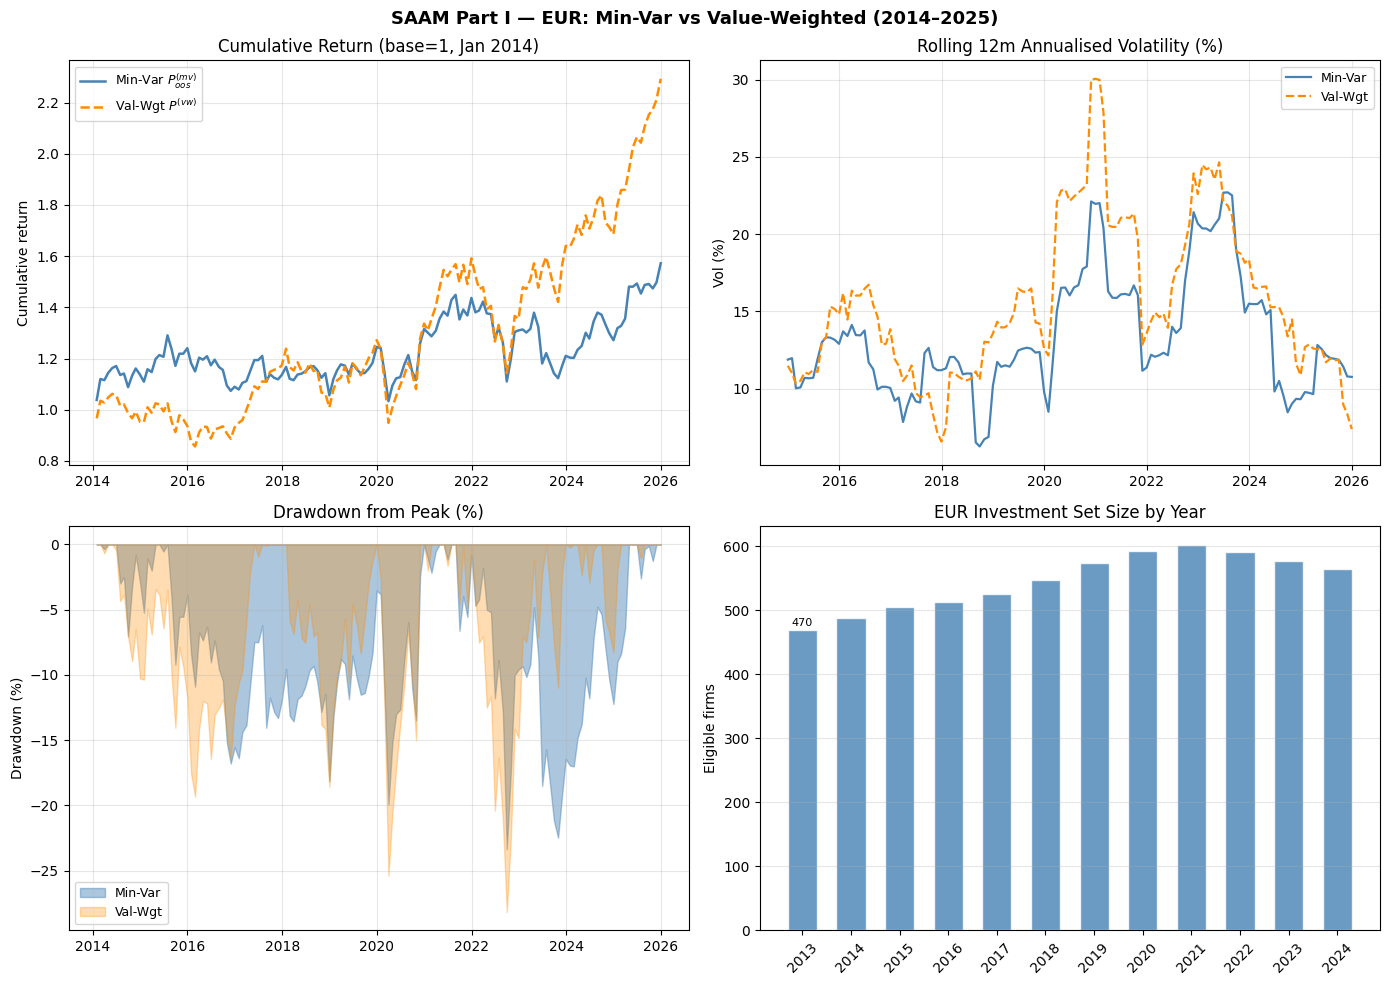

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [16]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("SAAM Part I — EUR: Min-Var vs Value-Weighted (2014–2025)",
             fontsize=13, fontweight="bold")
C1, C2 = "steelblue", "darkorange"
fmt = mdates.DateFormatter("%Y")
loc = mdates.YearLocator(2)

ax = axes[0, 0]
cm = (1 + rp_mv.dropna()).cumprod()
cv = (1 + rp_vw.dropna()).cumprod()
ax.plot(cm.index, cm.values, color=C1, lw=1.8, label=r"Min-Var $P_{oos}^{(mv)}$")
ax.plot(cv.index, cv.values, color=C2, lw=1.8, ls="--", label=r"Val-Wgt $P^{(vw)}$")
ax.set_title("Cumulative Return (base=1, Jan 2014)")
ax.set_ylabel("Cumulative return")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(fmt)
ax.xaxis.set_major_locator(loc)

ax = axes[0, 1]
rv_mv = rp_mv.rolling(12).std() * np.sqrt(12) * 100
rv_vw = rp_vw.rolling(12).std() * np.sqrt(12) * 100
ax.plot(rp_mv.index, rv_mv.values, color=C1, lw=1.6, label="Min-Var")
ax.plot(rp_vw.index, rv_vw.values, color=C2, lw=1.6, ls="--", label="Val-Wgt")
ax.set_title("Rolling 12m Annualised Volatility (%)")
ax.set_ylabel("Vol (%)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(fmt)
ax.xaxis.set_major_locator(loc)

ax = axes[1, 0]


def drawdown_series(rp):
    c = (1 + rp.dropna()).cumprod()
    return (c - c.cummax()) / c.cummax() * 100


dd_mv = drawdown_series(rp_mv)
dd_vw = drawdown_series(rp_vw)
ax.fill_between(dd_mv.index, dd_mv.values, 0, alpha=0.45, color=C1, label="Min-Var")
ax.fill_between(dd_vw.index, dd_vw.values, 0, alpha=0.30, color=C2, label="Val-Wgt")
ax.set_title("Drawdown from Peak (%)")
ax.set_ylabel("Drawdown (%)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(fmt)
ax.xaxis.set_major_locator(loc)

ax = axes[1, 1]
yrs = sorted(universe.keys())
ax.bar(yrs, [len(universe[y]) for y in yrs], color=C1, alpha=0.8,
       edgecolor="white", width=0.6)
ax.set_title("EUR Investment Set Size by Year")
ax.set_ylabel("Eligible firms")
ax.set_xticks(yrs)
ax.set_xticklabels(yrs, rotation=45)
ax.grid(axis="y", alpha=0.3)
for y in yrs:
    ax.text(y, len(universe[y]) + 5, str(len(universe[y])), ha="center", fontsize=8)

    plt.tight_layout()
    plt.tight_layout()
    plt.savefig(f"{OUT}SAAM_Part1_EUR_figures.pdf", dpi=150, bbox_inches="tight")
    plt.show()

# PART II — Carbon-Aware Portfolio Allocation

## 15. Carbon Data Preparation

In [17]:


co2_tot = co2_s1 + co2_s2
rev_m = rev / 1000.0  # thousands → millions USD

with np.errstate(divide="ignore", invalid="ignore"):
    CI_firm = co2_tot / rev_m

## 16. Carbon Metrics — Baseline Portfolios

> ### Interrogation D — VW carbon coverage is 0.99, not 1.00
>
> The output table will show `cov_W ≈ 0.99` for the VW portfolio's WACI.
>
> **Cause:** a small number of EUR firms have CO₂ emissions reported but **missing revenue** → CI = NaN → those firms are excluded from the WACI numerator while still receiving market-cap weight in the denominator.
>
> **Effect:** small downward bias (~1%) in reported WACI for VW. Does not affect CF (which uses Cap, not Revenue).
>
> **For the report:** mention this in the "data quality" limitations bullet.


In [18]:


def carbon_metrics(weights, Y):
    """WACI (tCO2/M$rev) and CF (tCO2/M$inv) for a portfolio at year-end Y."""
    isins = list(weights.index)
    w = weights.values.astype(float)
    E = co2_tot.loc[isins, Y].values.astype(float)
    R = rev_m.loc[isins, Y].values.astype(float)
    C = mv_y.loc[isins, Y].values.astype(float)

    with np.errstate(divide="ignore", invalid="ignore"):
        CI = np.where((R > 0) & np.isfinite(R), E / R, np.nan)
    valid_W = np.isfinite(CI)
    WACI = float(np.nansum(w * np.where(valid_W, CI, 0.0)))
    cov_W = float(w[valid_W].sum())

    with np.errstate(divide="ignore", invalid="ignore"):
        ED = np.where((C > 0) & np.isfinite(C), E / C, np.nan)
    valid_F = np.isfinite(ED)
    CF = float(np.nansum(w * np.where(valid_F, ED, 0.0)))
    cov_F = float(w[valid_F].sum())

    return {"WACI": WACI, "CF": CF, "cov_W": cov_W, "cov_F": cov_F}


mv_carbon_rows, vw_carbon_rows = [], []
for Y in years:
    mv_carbon_rows.append({"Y": Y, **carbon_metrics(mv_w_dict[Y], Y)})
    vw_carbon_rows.append({"Y": Y, **carbon_metrics(vw_weights(Y), Y)})

mv_carbon = pd.DataFrame(mv_carbon_rows).set_index("Y")
vw_carbon = pd.DataFrame(vw_carbon_rows).set_index("Y")

_cm = mv_carbon[["WACI","CF"]].rename(columns={
    "WACI": "WACI (tCO₂/M$rev)", "CF": "CF (tCO₂/M$inv)"})
_cv = vw_carbon[["WACI","CF"]].rename(columns={
    "WACI": "WACI (tCO₂/M$rev)", "CF": "CF (tCO₂/M$inv)"})
display(_cm.style
        .set_caption("Min-Variance P^(mv)_oos — Carbon Metrics by Year")
        .format("{:.2f}")
        .background_gradient(cmap="YlOrRd")
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))
display(_cv.style
        .set_caption("Value-Weighted P^(vw) — Carbon Metrics by Year")
        .format("{:.2f}")
        .background_gradient(cmap="YlOrRd")
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))


,WACI (tCO₂/M$rev),CF (tCO₂/M$inv)
Y,,
2013,56.40,25.77
2014,97.12,496.07
2015,62.75,78.11
2016,91.39,363.54
2017,192.92,257.09
2018,106.82,137.90
2019,73.29,30.61
2020,139.51,54.88
2021,128.69,39.70


,WACI (tCO₂/M$rev),CF (tCO₂/M$inv)
Y,,
2013,135.32,213.06
2014,126.40,184.41
2015,154.36,192.33
2016,149.53,204.42
2017,170.68,184.43
2018,134.35,143.17
2019,138.49,152.67
2020,131.58,124.57
2021,133.42,117.14


## 18. Top Carbon Contributors

In [19]:
# Top 10 carbon-intensive firms — snapshot years
def top_n_by_CI(Y, n=10):
    isins = universe[Y]
    CI = (co2_tot.loc[isins, Y] / rev_m.loc[isins, Y]).dropna().sort_values(ascending=False)
    rows = []
    for rk, isin in enumerate(CI.head(n).index, 1):
        cty = static.loc[static["ISIN"] == isin, "Country"].values
        rows.append({"Rank": rk,
                     "Name": isin_name.get(isin, isin),
                     "Country": cty[0] if len(cty) else "",
                     "CI (tCO₂/M$rev)": round(float(CI.loc[isin]), 1),
                     "VW weight (%)": round(float(vw_weights(Y).get(isin, 0)) * 100, 3)})
    return pd.DataFrame(rows)

snapshot_years = [2013, 2018, 2024]

for Y in snapshot_years:
    _df = top_n_by_CI(Y)
    display(_df.style
              .set_caption(f"Top 10 Carbon-Intensive Firms in EUR Universe — {Y}")
              .hide(axis="index")
              .format({"CI (tCO₂/M$rev)": "{:,.1f}", "VW weight (%)": "{:.3f}"})
              .bar(subset=["CI (tCO₂/M$rev)"], color="#e05c2d", vmin=0)
              .set_table_styles([{"selector":"caption","props":
                  [("font-weight","bold"),("font-size","13px")]}]))


Rank,Name,Country,CI (tCO₂/M$rev),VW weight (%)
1,DRAX GROUP,GB,"7,356.0",0.047
2,BUZZI,IT,"5,670.9",0.030
3,HOLCIM,CH,"4,279.1",0.318
4,HEIDELBERG MATERIALS,DE,"3,083.0",0.150
5,FORTUM,FI,"2,491.2",0.210
6,RWE,DE,"2,405.9",0.270
7,SSAB A,SE,"1,736.6",0.025
8,ENDESA,ES,"1,260.7",0.309
9,SECHE ENVIRONNEMENT,FR,"1,252.1",0.004
10,ICTL.HTLS.GP.,GB,"1,213.3",0.112


Rank,Name,Country,CI (tCO₂/M$rev),VW weight (%)
1,BUZZI,IT,"6,045.7",0.044
2,HOLCIM,CH,"4,601.3",0.337
3,HEIDELBERG MATERIALS,DE,"3,697.3",0.195
4,FORTUM,FI,"3,592.8",0.180
5,EVRAZ SUSP - SUSP.06/12/23,GB,"3,302.7",0.068
6,SBM OFFSHORE,NL,"2,608.9",0.035
7,RWE,DE,"2,376.0",0.102
8,PHAROS ENERGY,GB,"2,179.3",0.005
9,FERREXPO,CH,"1,918.8",0.021
10,YARA INTERNATIONAL,NO,"1,496.6",0.119


Rank,Name,Country,CI (tCO₂/M$rev),VW weight (%)
1,TITAN,BE,"4,102.6",0.017
2,BUZZI,IT,"4,043.3",0.054
3,AEP PLANTATIONS,GB,"3,224.3",0.003
4,HEIDELBERG MATERIALS,DE,"2,965.0",0.143
5,EVRAZ SUSP - SUSP.06/12/23,GB,"2,859.7",0.012
6,HOLCIM,CH,"2,403.7",0.364
7,REA HOLDINGS,GB,"2,325.3",0.000
8,PHAROS ENERGY,GB,"2,166.3",0.001
9,RWE,DE,"1,738.1",0.224
10,L AIR LQE.SC.ANYME. POUR L ETUDE ET L EPXTN.,FR,"1,192.1",0.806


## 19. Plot — Carbon Metrics Time Series

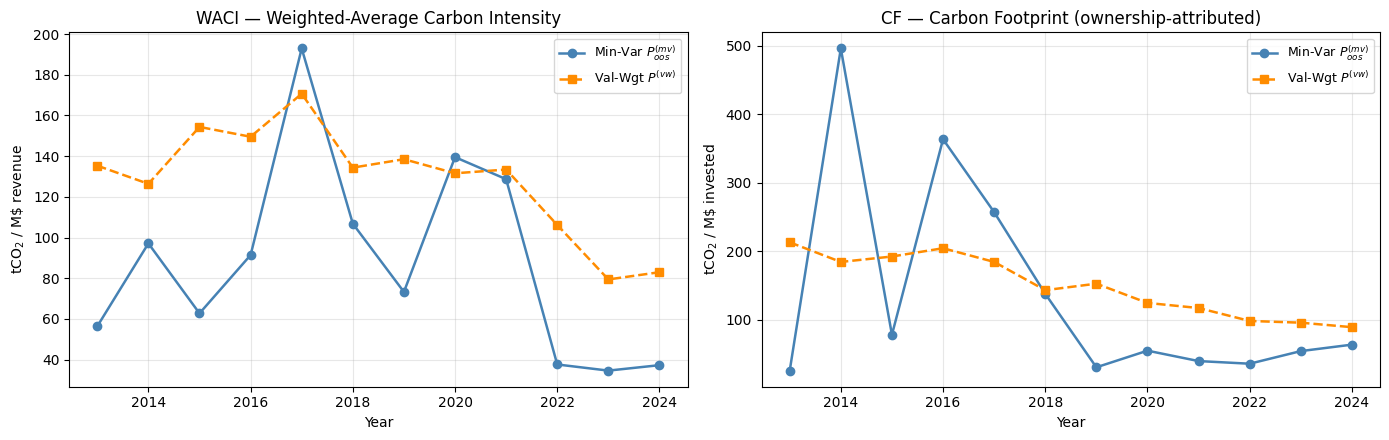

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
C1, C2 = "steelblue", "darkorange"

ax = axes[0]
ax.plot(mv_carbon.index, mv_carbon["WACI"], "o-", color=C1, lw=1.8,
        label=r"Min-Var $P^{(mv)}_{oos}$")
ax.plot(vw_carbon.index, vw_carbon["WACI"], "s--", color=C2, lw=1.8,
        label=r"Val-Wgt $P^{(vw)}$")
ax.set_title("WACI — Weighted-Average Carbon Intensity")
ax.set_xlabel("Year")
ax.set_ylabel(r"tCO$_2$ / M\$ revenue")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(mv_carbon.index, mv_carbon["CF"], "o-", color=C1, lw=1.8,
        label=r"Min-Var $P^{(mv)}_{oos}$")
ax.plot(vw_carbon.index, vw_carbon["CF"], "s--", color=C2, lw=1.8,
        label=r"Val-Wgt $P^{(vw)}$")
ax.set_title("CF — Carbon Footprint (ownership-attributed)")
ax.set_xlabel("Year")
ax.set_ylabel(r"tCO$_2$ / M\$ invested")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.tight_layout()
plt.savefig(f"{OUT}SAAM_Part2_carbon_baseline.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Section 3.2 — Active Investor: MV with CF ≤ 0.5 × CF(MV)

## 19. CF Targets and Feasibility

In [21]:

cf_target_mv = (mv_carbon["CF"] * 0.5).rename("target_CF").copy()
display(cf_target_mv.to_frame("CF Target (tCO₂/M$inv)")
        .style.set_caption("CF Targets — P^(mv)_oos(0.5): 50% of MV baseline")
        .format("{:.3f}")
        .background_gradient(cmap="Greens_r")
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))


def cf_vector(isins, Y):
    """c_i = E_i,Y / Cap_i,Y (inf where cap missing — forces α_i = 0)."""
    E = co2_tot.loc[isins, Y].values.astype(float)
    C = mv_y.loc[isins, Y].values.astype(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        c = np.where((C > 0) & np.isfinite(C) & np.isfinite(E), E / C, np.inf)
    return c, np.isfinite(c)


_mfcf_cache = {}


def get_min_cf(Y):
    """Minimum achievable CF for the year-Y universe (LP)."""
    if Y not in _mfcf_cache:
        isins = universe[Y]
        c, valid = cf_vector(isins, Y)
        N = len(isins)
        if not valid.any():
            _mfcf_cache[Y] = np.nan
        else:
            c_lp = np.where(valid, c, 1e20)
            res = linprog(c=c_lp, A_eq=np.ones((1, N)), b_eq=[1.0],
                          bounds=[(0.0, 1.0)] * N, method="highs")
            _mfcf_cache[Y] = float(c_lp @ res.x) if res.success else np.nan
    return _mfcf_cache[Y]


adj_targets = {}
for Y in years:
    cf_min = get_min_cf(Y)
    target_raw = float(cf_target_mv.loc[Y])
    if cf_min > target_raw:
        adj_targets[Y] = cf_min * 1.001
        print(f"   Y={Y}: target relaxed from {target_raw:.3f} to {adj_targets[Y]:.3f}")
    else:
        adj_targets[Y] = target_raw
display(cf_target_mv.to_frame("CF Target (tCO₂/M$inv)")
        .style.set_caption("CF Targets — P^(mv)_oos(0.5): 50% of MV baseline")
        .format("{:.3f}")
        .background_gradient(cmap="Greens_r")
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))


,CF Target (tCO₂/M$inv)
Y,
2013,12.883
2014,248.036
2015,39.053
2016,181.770
2017,128.547
2018,68.948
2019,15.304
2020,27.441
2021,19.849


,CF Target (tCO₂/M$inv)
Y,
2013,12.883
2014,248.036
2015,39.053
2016,181.770
2017,128.547
2018,68.948
2019,15.304
2020,27.441
2021,19.849


## 20. Constrained Min-Variance Optimizer

In [22]:
def min_var_cf_constrained(Sigma, c, target, isins, Y, prev_drift=None):
    N = Sigma.shape[0]
    valid = np.isfinite(c)
    invalid = ~valid

    if prev_drift is not None:
        w0 = np.array([prev_drift.get(i, 0.0) for i in isins])
        w0[invalid] = 0.0
        s = w0.sum()
        w0 = w0 / s if s > 0 else np.where(valid, 1.0, 0.0) / max(valid.sum(), 1)
    else:
        w0 = np.where(valid, 1.0, 0.0) / max(valid.sum(), 1)

    bounds = [(0.0, 0.0) if invalid[i] else (0.0, 1.0) for i in range(N)]
    c_safe = np.where(valid, c, 0.0)
    constraints = [
        {"type": "eq", "fun": lambda w: w.sum() - 1.0, "jac": lambda w: np.ones(N)},
        {"type": "ineq", "fun": lambda w: target - c_safe @ w, "jac": lambda w: -c_safe},
    ]
    return minimize(
        fun=lambda w: float(w @ Sigma @ w),
        x0=w0, jac=lambda w: 2.0 * (Sigma @ w),
        method="SLSQP", bounds=bounds, constraints=constraints,
        options={"ftol": 1e-10, "maxiter": 2000},
    )

## 21. Rolling Loop — P^(mv)_oos(0.5)

In [23]:

mv05_w_dict = {}
mv05_ret = {}
_mv05_drift = {}

for Y in years:
    eligible = universe[Y]
    target = adj_targets[Y]
    _, Sig = get_cov(Y)
    c, valid = cf_vector(eligible, Y)

    res = min_var_cf_constrained(Sig, c, target, eligible, Y,
                                  prev_drift=_mv05_drift.get(Y))
    w = np.clip(res.x, 0.0, 1.0)
    if w.sum() > 0:
        w /= w.sum()

    mv05_w_dict[Y] = pd.Series(w, index=eligible)

    R_next = get_oos_returns(Y)
    next_months = _months_of[Y + 1]
    ww = w.copy()
    port_ret = []
    for t in next_months:
        r_t = R_next[t].values
        rp_t = float(ww @ r_t)
        port_ret.append(rp_t)
        ww = ww * (1.0 + r_t) / max(1.0 + rp_t, 1e-12)
    mv05_ret[Y + 1] = pd.Series(port_ret, index=next_months)
    _mv05_drift[Y + 1] = dict(zip(eligible, ww))

rp_mv05 = pd.concat(mv05_ret).droplevel(0).sort_index()
rp_mv05.index = pd.DatetimeIndex(rp_mv05.index)

## 22. Verification — MV05

In [24]:
mv05_carbon = pd.DataFrame(
    [{"Y": Y, **carbon_metrics(mv05_w_dict[Y], Y)} for Y in years]
).set_index("Y")

cf_check = pd.DataFrame({
    "target_eff": pd.Series(adj_targets),
    "CF_realized": mv05_carbon["CF"],
})
cf_check["slack"] = cf_check["target_eff"] - cf_check["CF_realized"]

def _slack_color(v):
    try:
        return "background-color:#c6efce" if abs(float(v)) < 0.01 else "background-color:#fff2cc"
    except (TypeError, ValueError):
        return ""

display(cf_check.style
        .set_caption("MV(0.5) — CF constraint verification  (slack ≈ 0 → binding constraint)")
        .format("{:.3f}")
        .map(_slack_color, subset=["slack"])
        .set_table_styles([{"selector": "caption",
                            "props": [("font-weight", "bold"), ("font-size", "13px")]}]))


,target_eff,CF_realized,slack
2013,12.883,12.883,-0.000
2014,248.036,248.036,-0.000
2015,39.053,39.053,-0.000
2016,181.770,181.770,-0.000
2017,128.547,128.547,-0.000
2018,68.948,68.948,-0.000
2019,15.304,15.304,-0.000
2020,27.441,27.441,-0.000
2021,19.849,19.849,-0.000
2022,17.919,17.919,-0.000


## 23. Performance — MV05

> ### Interrogation C (part 1/2) — "Decarbonization is free" for MV: true here, but partly a regional artifact
>
> Expected output: MV(0.5) Sharpe 0.217 vs MV 0.218 — essentially **zero Sharpe cost** for halving the carbon footprint.
>
> **Why this looks too good to be true:**
> - The heaviest EUR carbon emitters (Holcim, RWE, Heidelberg, Buzzi) have **near-zero MV weights to begin with** — they're high-vol, so MV already excludes them.
> - The 50% CF cut is therefore satisfied by minor reweighting among already-low-emission defensive names.
>
> **Honest framing for the report and for the sales pitch (deliverable #2):**
> - In Europe, this conclusion is genuine.
> - The same exercise on a North American (oil & gas heavyweights) or Asian (steel, cement) universe would likely show real cost.
> - **Don't generalize beyond the EUR sample without saying so.**


In [25]:
stats_mv05 = pd.DataFrame([
    compute_perf(rp_mv, rf_mon, "P^(mv)_oos"),
    compute_perf(rp_mv05, rf_mon, "P^(mv)_oos(0.5)"),
    compute_perf(rp_vw, rf_mon, "P^(vw) (benchmark)"),
]).set_index("Portfolio")
display(stats_mv05.style
        .set_caption("Section 3.2 — Performance: MV vs MV(0.5) vs VW")
        .format({"Ann. Return Arith. (%)": "{:.2f}", "Ann. Return Geom. (%)": "{:.2f}",
                 "Ann. Vol (%)": "{:.2f}", "Sharpe": "{:.3f}",
                 "Min Mo. (%)": "{:.2f}", "Max Mo. (%)": "{:.2f}", "Max DD (%)": "{:.2f}"})
        .highlight_min(subset=["Ann. Vol (%)","Max DD (%)"], color="#c6efce")
        .highlight_max(subset=["Sharpe","Ann. Return Arith. (%)"], color="#ffeb9c")
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))


,Ann. Return Arith. (%),Ann. Return Geom. (%),Ann. Vol (%),Sharpe,Min Mo. (%),Max Mo. (%),Max DD (%)
Portfolio,,,,,,,
P^(mv)_oos,4.67,3.84,13.39,0.218,-12.01,12.79,-23.36
P^(mv)_oos(0.5),4.67,3.83,13.43,0.217,-12.10,12.57,-23.64
P^(vw) (benchmark),8.19,7.16,15.87,0.406,-15.34,18.27,-28.17


## 23. Composition Shifts — MV05 vs MV

In [26]:
# Composition shifts: MV(0.5) vs MV
def composition_diff_df(Y, top_n=5):
    w_mv  = mv_w_dict[Y].reindex(universe[Y]).fillna(0.0)
    w_mv5 = mv05_w_dict[Y].reindex(universe[Y]).fillna(0.0)
    diff = (w_mv5 - w_mv).sort_values()
    rows = []
    for isin, dlt in list(diff.head(top_n).items()) + list(diff.tail(top_n).iloc[::-1].items()):
        ci_val = float(co2_tot.loc[isin, Y] / rev_m.loc[isin, Y]) if (
            isin in co2_tot.index and isin in rev_m.index and
            Y in co2_tot.columns and Y in rev_m.columns and
            rev_m.loc[isin, Y] > 0) else float("nan")
        rows.append({"Name": isin_name.get(isin, isin)[:40],
                     "Direction": "Removed ↓" if dlt < 0 else "Added ↑",
                     "Δ Weight (pp)": round(dlt * 100, 2),
                     "CI (tCO₂/M$rev)": round(ci_val, 1) if not pd.isna(ci_val) else "n/a"})
    return pd.DataFrame(rows)

def _direction_color(v):
    if v == "Removed ↓":
        return "color:#c0392b;font-weight:bold"
    elif v == "Added ↑":
        return "color:#1a6b1a;font-weight:bold"
    return ""

for Y in snapshot_years:
    _df = composition_diff_df(Y)
    display(_df.style
              .set_caption(f"Y={Y} — Portfolio tilt: MV(0.5) vs MV (top 5 removed / added)")
              .hide(axis="index")
              .format({"Δ Weight (pp)": "{:+.2f}"})
              .map(_direction_color, subset=["Direction"])
              .set_table_styles([{"selector": "caption",
                                  "props": [("font-weight", "bold"), ("font-size", "13px")]}]))


Name,Direction,Δ Weight (pp),CI (tCO₂/M$rev)
UNITED UTILITIES GROUP,Removed ↓,-4.62,178.800000
NATIONAL GRID,Removed ↓,-3.20,389.100000
DEVRO DEAD - DELIST.14/04/23,Removed ↓,-1.79,387.000000
TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,Removed ↓,-1.63,51.800000
DE LA RUE ORD DEAD - DELIST.03/07/25,Removed ↓,-1.19,106.400000
SWISSCOM 'R',Added ↑,+2.93,2.000000
DIGNITY DEAD - DELIST.25/05/23,Added ↑,+2.01,61.500000
MEDTRONIC,Added ↑,+1.78,12.300000
COLOPLAST B,Added ↑,+1.76,21.000000
CHUBB,Added ↑,+1.75,3.000000


Name,Direction,Δ Weight (pp),CI (tCO₂/M$rev)
NATIONAL GRID,Removed ↓,-1.60,334.000000
EVRAZ SUSP - SUSP.06/12/23,Removed ↓,-1.26,3302.700000
COLOPLAST B,Removed ↓,-0.63,20.600000
CHUBB,Removed ↓,-0.54,2.300000
COMPASS GROUP,Removed ↓,-0.48,4.300000
SCHINDLER 'R',Added ↑,+1.00,17.400000
COCA-COLA HBC,Added ↑,+0.75,77.700000
BIOMERIEUX,Added ↑,+0.72,23.200000
UNITED UTILITIES GROUP,Added ↑,+0.56,142.600000
JOHNSON CONTROLS INTL.,Added ↑,+0.55,33.900000


Name,Direction,Δ Weight (pp),CI (tCO₂/M$rev)
CAMELLIA,Removed ↓,-2.51,582.800000
SWISSCOM 'R',Removed ↓,-0.49,4.200000
EBRO FOODS,Removed ↓,-0.36,81.400000
BEZEQ ISRAELI TELECOMMUNICATION,Removed ↓,-0.33,53.900000
CHUBB,Removed ↓,-0.26,1.800000
VALIANT 'R',Added ↑,+0.75,1.400000
DIAGEO,Added ↑,+0.57,26.300000
FIRST INTL.BK.OF ISR.,Added ↑,+0.54,3.400000
RHOEN-KLINIKUM,Added ↑,+0.45,34.900000
JYSKE BANK,Added ↑,+0.41,0.400000


## 25. Plots — Section 3.2

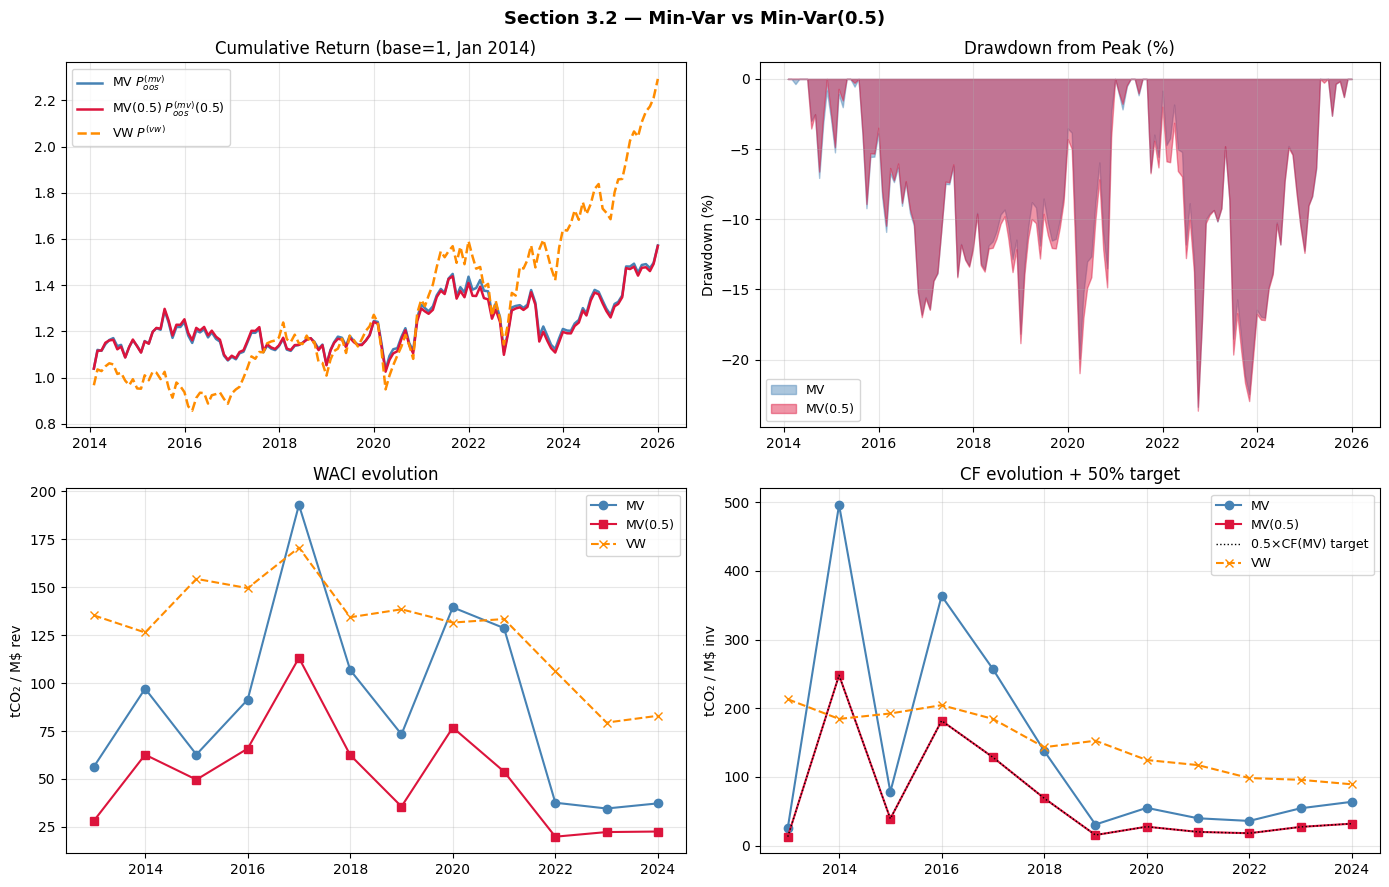

In [27]:

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Section 3.2 — Min-Var vs Min-Var(0.5)", fontsize=13, fontweight="bold")
C1, C2, C3 = "steelblue", "crimson", "darkorange"
fmt = mdates.DateFormatter("%Y")
loc = mdates.YearLocator(2)

ax = axes[0, 0]
for rp, color, ls, lab in [(rp_mv, C1, "-", r"MV $P^{(mv)}_{oos}$"),
                           (rp_mv05, C2, "-", r"MV(0.5) $P^{(mv)}_{oos}(0.5)$"),
                           (rp_vw, C3, "--", r"VW $P^{(vw)}$")]:
    cum = (1 + rp.dropna()).cumprod()
    ax.plot(cum.index, cum.values, color=color, ls=ls, lw=1.8, label=lab)
ax.set_title("Cumulative Return (base=1, Jan 2014)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(fmt)
ax.xaxis.set_major_locator(loc)

ax = axes[0, 1]


def dd(rp):
    c = (1 + rp.dropna()).cumprod()
    return (c - c.cummax()) / c.cummax() * 100


ax.fill_between(dd(rp_mv).index, dd(rp_mv).values, 0, alpha=0.45, color=C1, label="MV")
ax.fill_between(dd(rp_mv05).index, dd(rp_mv05).values, 0, alpha=0.45, color=C2, label="MV(0.5)")
ax.set_title("Drawdown from Peak (%)")
ax.set_ylabel("Drawdown (%)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(fmt)
ax.xaxis.set_major_locator(loc)

ax = axes[1, 0]
ax.plot(mv_carbon.index, mv_carbon["WACI"], "o-", color=C1, label="MV")
ax.plot(mv05_carbon.index, mv05_carbon["WACI"], "s-", color=C2, label="MV(0.5)")
ax.plot(vw_carbon.index, vw_carbon["WACI"], "x--", color=C3, label="VW")
ax.set_title("WACI evolution")
ax.set_ylabel("tCO₂ / M$ rev")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(mv_carbon.index, mv_carbon["CF"], "o-", color=C1, label="MV")
ax.plot(mv05_carbon.index, mv05_carbon["CF"], "s-", color=C2, label="MV(0.5)")
ax.plot(cf_target_mv.index, cf_target_mv.values, "k:", lw=1, label="0.5×CF(MV) target")
ax.plot(vw_carbon.index, vw_carbon["CF"], "x--", color=C3, label="VW")
ax.set_title("CF evolution + 50% target")
ax.set_ylabel("tCO₂ / M$ inv")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.tight_layout()
plt.savefig(f"{OUT}SAAM_Part2_section32.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Section 3.3 — Passive Investor: TE-Min with CF ≤ 0.5 × CF(VW)

## 26. CF Targets for VW

In [28]:

cf_target_vw = (vw_carbon["CF"] * 0.5).rename("target_CF").copy()
display(cf_target_vw.to_frame("CF Target (tCO₂/M$inv)")
        .style.set_caption("CF Targets — P^(vw)_oos(0.5): 50% of VW baseline")
        .format("{:.3f}")
        .background_gradient(cmap="Greens_r")
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))

adj_targets_vw = {}
for Y in years:
    cf_min = get_min_cf(Y)
    target_raw = float(cf_target_vw.loc[Y])
    if cf_min > target_raw:
        adj_targets_vw[Y] = cf_min * 1.001
        print(f"   Y={Y}: target relaxed from {target_raw:.3f} to {adj_targets_vw[Y]:.3f}")
    else:
        adj_targets_vw[Y] = target_raw
display(cf_target_vw.to_frame("CF Target (tCO₂/M$inv)")
        .style.set_caption("CF Targets — P^(vw)_oos(0.5): 50% of VW baseline")
        .format("{:.3f}")
        .background_gradient(cmap="Greens_r")
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))


,CF Target (tCO₂/M$inv)
Y,
2013,106.529
2014,92.205
2015,96.166
2016,102.209
2017,92.217
2018,71.586
2019,76.335
2020,62.284
2021,58.570


,CF Target (tCO₂/M$inv)
Y,
2013,106.529
2014,92.205
2015,96.166
2016,102.209
2017,92.217
2018,71.586
2019,76.335
2020,62.284
2021,58.570


## 27. TE-Min Optimizer with CF Constraint

In [29]:
def min_te_cf_constrained(Sigma, w_bench, c, target, isins):
    N = Sigma.shape[0]
    valid = np.isfinite(c)
    invalid = ~valid
    w0 = w_bench.copy()
    w0[invalid] = 0.0
    s = w0.sum()
    w0 = w0 / s if s > 0 else np.where(valid, 1.0, 0.0) / max(valid.sum(), 1)

    bounds = [(0.0, 0.0) if invalid[i] else (0.0, 1.0) for i in range(N)]
    c_safe = np.where(valid, c, 0.0)
    constraints = [
        {"type": "eq", "fun": lambda w: w.sum() - 1.0, "jac": lambda w: np.ones(N)},
        {"type": "ineq", "fun": lambda w: target - c_safe @ w, "jac": lambda w: -c_safe},
    ]
    return minimize(
        fun=lambda w: float((w - w_bench) @ Sigma @ (w - w_bench)),
        x0=w0, jac=lambda w: 2.0 * (Sigma @ (w - w_bench)),
        method="SLSQP", bounds=bounds, constraints=constraints,
        options={"ftol": 1e-10, "maxiter": 3000},
    )

## 28. Rolling VW(0.5) Optimization

In [30]:

vw05_w_dict = {}
vw05_ret = {}

for Y in years:
    eligible = universe[Y]
    target = adj_targets_vw[Y]
    _, Sig = get_cov(Y)
    c, valid = cf_vector(eligible, Y)
    w_bench = vw_weights(Y).reindex(eligible).fillna(0.0).values

    res = min_te_cf_constrained(Sig, w_bench, c, target, eligible)
    w = np.clip(res.x, 0.0, 1.0)
    if w.sum() > 0:
        w /= w.sum()

    vw05_w_dict[Y] = pd.Series(w, index=eligible)

    R_next = get_oos_returns(Y)
    next_months = _months_of[Y + 1]
    ww = w.copy()
    port_ret = []
    for t in next_months:
        r_t = R_next[t].values
        rp_t = float(ww @ r_t)
        port_ret.append(rp_t)
        ww = ww * (1.0 + r_t) / max(1.0 + rp_t, 1e-12)
    vw05_ret[Y + 1] = pd.Series(port_ret, index=next_months)

rp_vw05 = pd.concat(vw05_ret).droplevel(0).sort_index()
rp_vw05.index = pd.DatetimeIndex(rp_vw05.index)

## 29. Verification — VW05

In [31]:

vw05_carbon = pd.DataFrame(
    [{"Y": Y, **carbon_metrics(vw05_w_dict[Y], Y)} for Y in years]
).set_index("Y")
cf_check_vw = pd.DataFrame({
    "target_eff": pd.Series(adj_targets_vw),
    "CF_realized": vw05_carbon["CF"],
})
display(cf_check_vw.style
        .set_caption("VW(0.5) — CF constraint verification")
        .format("{:.3f}")
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))


,target_eff,CF_realized
2013,106.529,106.529
2014,92.205,92.205
2015,96.166,96.166
2016,102.209,102.209
2017,92.217,92.217
2018,71.586,71.586
2019,76.335,76.335
2020,62.284,62.284
2021,58.570,58.570
2022,49.139,49.139


## 30. Performance — VW05

> ### Interrogation C (part 2/2) — VW(0.5) cost is small but non-zero
>
> Expected output: VW(0.5) Sharpe 0.381 vs VW 0.406 — about **6% Sharpe reduction** for halving CF.
> In return terms: arithmetic return drops 8.19% → 7.86% (~33 bps/yr).
>
> **Same regional reason as MV(0.5):** even Holcim, the largest EUR emitter, is only ~0.36% of EUR market cap. So a 50% CF cut requires only modest reweighting away from a few names — not a sector-level overhaul.
>


In [32]:
stats_vw05 = pd.DataFrame([
    compute_perf(rp_vw, rf_mon, "P^(vw) (benchmark)"),
    compute_perf(rp_vw05, rf_mon, "P^(vw)_oos(0.5)"),
    compute_perf(rp_mv05, rf_mon, "P^(mv)_oos(0.5) [reference]"),
]).set_index("Portfolio")
display(stats_vw05.style
        .set_caption("Section 3.3 — Performance: VW vs VW(0.5) vs MV(0.5)")
        .format({"Ann. Return Arith. (%)": "{:.2f}", "Ann. Return Geom. (%)": "{:.2f}",
                 "Ann. Vol (%)": "{:.2f}", "Sharpe": "{:.3f}",
                 "Min Mo. (%)": "{:.2f}", "Max Mo. (%)": "{:.2f}", "Max DD (%)": "{:.2f}"})
        .highlight_min(subset=["Ann. Vol (%)","Max DD (%)"], color="#c6efce")
        .highlight_max(subset=["Sharpe","Ann. Return Arith. (%)"], color="#ffeb9c")
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))


,Ann. Return Arith. (%),Ann. Return Geom. (%),Ann. Vol (%),Sharpe,Min Mo. (%),Max Mo. (%),Max DD (%)
Portfolio,,,,,,,
P^(vw) (benchmark),8.19,7.16,15.87,0.406,-15.34,18.27,-28.17
P^(vw)_oos(0.5),7.86,6.79,16.04,0.381,-16.02,18.77,-27.97
P^(mv)_oos(0.5) [reference],4.67,3.83,13.43,0.217,-12.10,12.57,-23.64


## 31. Plots — Section 3.3

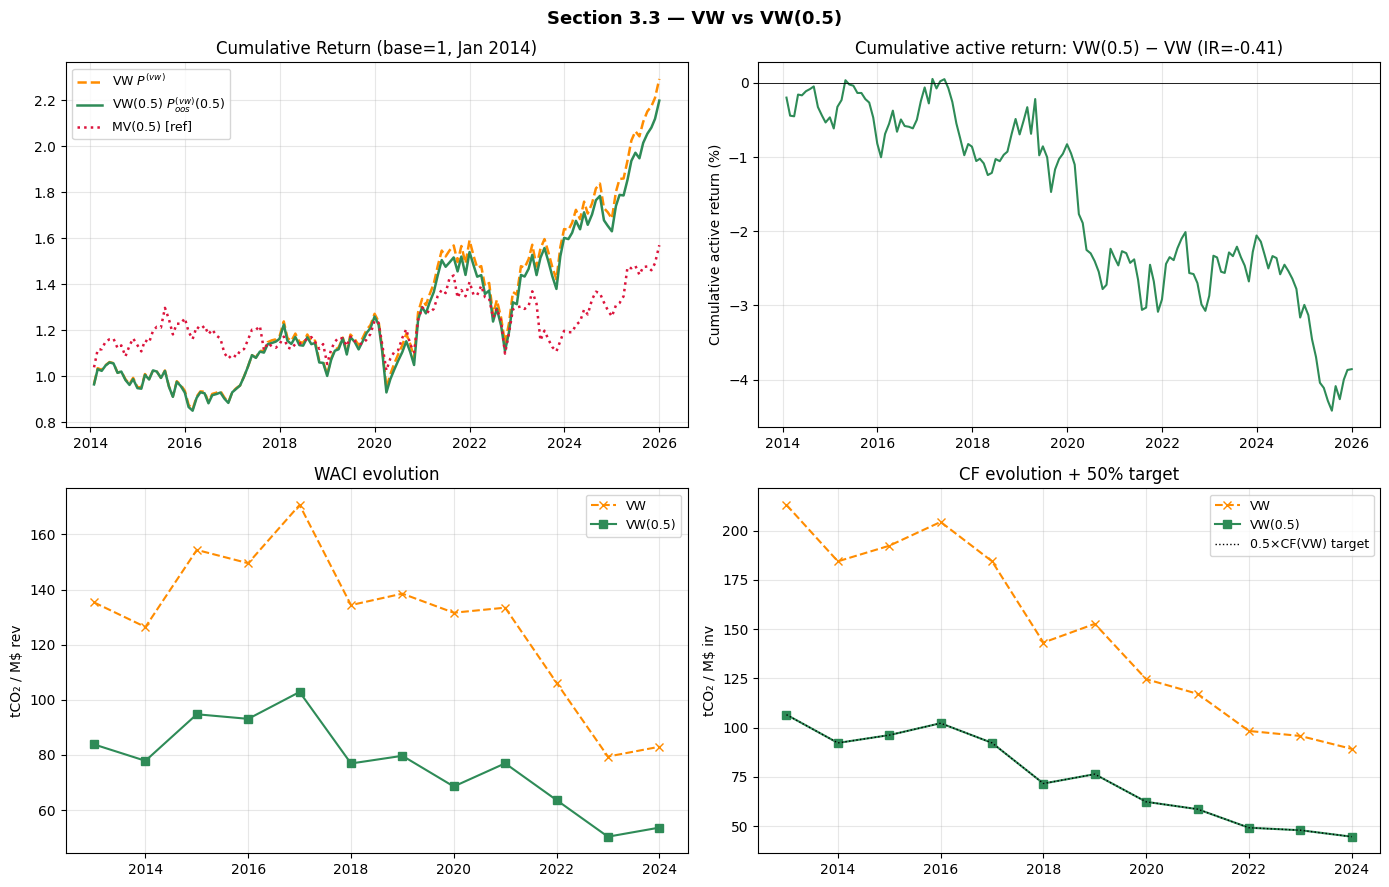

In [33]:

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Section 3.3 — VW vs VW(0.5)", fontsize=13, fontweight="bold")
C_VW, C_VW5, C_MV5 = "darkorange", "seagreen", "crimson"

ax = axes[0, 0]
for rp, color, ls, lab in [
    (rp_vw, C_VW, "--", r"VW $P^{(vw)}$"),
    (rp_vw05, C_VW5, "-", r"VW(0.5) $P^{(vw)}_{oos}(0.5)$"),
    (rp_mv05, C_MV5, ":", r"MV(0.5) [ref]"),
]:
    cum = (1 + rp.dropna()).cumprod()
    ax.plot(cum.index, cum.values, color=color, ls=ls, lw=1.8, label=lab)
ax.set_title("Cumulative Return (base=1, Jan 2014)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(fmt)
ax.xaxis.set_major_locator(loc)

ax = axes[0, 1]
ar = (rp_vw05 - rp_vw).dropna()
te_ep = ar.std() * np.sqrt(12) * 100
ir = ar.mean() * 12 / (ar.std() * np.sqrt(12)) if ar.std() > 0 else np.nan
ar_cum = (1 + ar).cumprod()
ax.plot(ar_cum.index, (ar_cum - 1) * 100, color=C_VW5, lw=1.5)
ax.axhline(0, color="k", lw=0.6)
ax.set_title(f"Cumulative active return: VW(0.5) − VW (IR={ir:.2f})")
ax.set_ylabel("Cumulative active return (%)")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(fmt)
ax.xaxis.set_major_locator(loc)

ax = axes[1, 0]
ax.plot(vw_carbon.index, vw_carbon["WACI"], "x--", color=C_VW, label="VW")
ax.plot(vw05_carbon.index, vw05_carbon["WACI"], "s-", color=C_VW5, label="VW(0.5)")
ax.set_title("WACI evolution")
ax.set_ylabel("tCO₂ / M$ rev")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(vw_carbon.index, vw_carbon["CF"], "x--", color=C_VW, label="VW")
ax.plot(vw05_carbon.index, vw05_carbon["CF"], "s-", color=C_VW5, label="VW(0.5)")
ax.plot(cf_target_vw.index, cf_target_vw.values, "k:", lw=1, label="0.5×CF(VW) target")
ax.set_title("CF evolution + 50% target")
ax.set_ylabel("tCO₂ / M$ inv")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.tight_layout()
plt.savefig(f"{OUT}SAAM_Part2_section33.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Section 4.1 — Net-Zero Glide Path

## 32. NZ Target Calculation

In [34]:


THETA = 0.10
CF_VW_2013 = float(vw_carbon.loc[2013, "CF"])


def nz_target(Y):
    return (1.0 - THETA) ** (Y - 2013 + 1) * CF_VW_2013


cf_target_nz = pd.Series({Y: nz_target(Y) for Y in years}, name="target_CF")

adj_targets_nz = {}
for Y in years:
    cf_min = get_min_cf(Y)
    target_raw = float(cf_target_nz.loc[Y])
    if cf_min > target_raw:
        adj_targets_nz[Y] = cf_min * 1.001
    else:
        adj_targets_nz[Y] = target_raw


_nz_targets_df = pd.DataFrame({
    "Raw NZ Target": cf_target_nz,
    "Effective Target": pd.Series(adj_targets_nz),
})
display(_nz_targets_df.style
        .set_caption(f"Net-Zero glide path — targets (θ={THETA:.0%}, 2013 CF={CF_VW_2013:.1f} tCO₂/M$inv)")
        .format("{:.3f}")
        .background_gradient(cmap="Greens_r", subset=["Effective Target"])
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))

,Raw NZ Target,Effective Target
2013,191.752,191.752
2014,172.577,172.577
2015,155.319,155.319
2016,139.787,139.787
2017,125.809,125.809
2018,113.228,113.228
2019,101.905,101.905
2020,91.714,91.714
2021,82.543,82.543
2022,74.289,74.289


## 33. Rolling VW(NZ) Optimization

In [35]:

vwnz_w_dict = {}
vwnz_ret = {}

for Y in years:
    eligible = universe[Y]
    target = adj_targets_nz[Y]
    _, Sig = get_cov(Y)
    c, valid = cf_vector(eligible, Y)
    w_bench = vw_weights(Y).reindex(eligible).fillna(0.0).values

    res = min_te_cf_constrained(Sig, w_bench, c, target, eligible)
    w = np.clip(res.x, 0.0, 1.0)
    if w.sum() > 0:
        w /= w.sum()

    vwnz_w_dict[Y] = pd.Series(w, index=eligible)

    R_next = get_oos_returns(Y)
    next_months = _months_of[Y + 1]
    ww = w.copy()
    port_ret = []
    for t in next_months:
        r_t = R_next[t].values
        rp_t = float(ww @ r_t)
        port_ret.append(rp_t)
        ww = ww * (1.0 + r_t) / max(1.0 + rp_t, 1e-12)
    vwnz_ret[Y + 1] = pd.Series(port_ret, index=next_months)

rp_vwnz = pd.concat(vwnz_ret).droplevel(0).sort_index()
rp_vwnz.index = pd.DatetimeIndex(rp_vwnz.index)

## 34. Verification — VWNZ

In [36]:

vwnz_carbon = pd.DataFrame(
    [{"Y": Y, **carbon_metrics(vwnz_w_dict[Y], Y)} for Y in years]
).set_index("Y")
cf_check_nz = pd.DataFrame({
    "target_eff": pd.Series(adj_targets_nz),
    "CF_realized": vwnz_carbon["CF"],
    "pct_of_2013_CF": vwnz_carbon["CF"] / CF_VW_2013 * 100,
})
display(cf_check_nz.style
        .set_caption("VW(NZ) — Realized CF vs Net-Zero glide path target")
        .format("{:.3f}")
        .background_gradient(cmap="Greens_r", subset=["pct_of_2013_CF"])
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))


,target_eff,CF_realized,pct_of_2013_CF
2013,191.752,191.752,90.000
2014,172.577,172.577,81.000
2015,155.319,155.319,72.900
2016,139.787,139.787,65.610
2017,125.809,125.809,59.049
2018,113.228,113.228,53.144
2019,101.905,101.905,47.830
2020,91.714,91.714,43.047
2021,82.543,82.543,38.742
2022,74.289,74.289,34.868


## 35. Performance — All Passive

In [37]:
stats_nz = pd.DataFrame([
    compute_perf(rp_vw, rf_mon, "P^(vw)"),
    compute_perf(rp_vw05, rf_mon, "P^(vw)_oos(0.5)"),
    compute_perf(rp_vwnz, rf_mon, "P^(vw)_oos(NZ)"),
]).set_index("Portfolio")
display(stats_nz.style
        .set_caption("Section 4.1 — Performance: VW vs VW(0.5) vs VW(NZ)")
        .format({"Ann. Return Arith. (%)": "{:.2f}", "Ann. Return Geom. (%)": "{:.2f}",
                 "Ann. Vol (%)": "{:.2f}", "Sharpe": "{:.3f}",
                 "Min Mo. (%)": "{:.2f}", "Max Mo. (%)": "{:.2f}", "Max DD (%)": "{:.2f}"})
        .highlight_min(subset=["Ann. Vol (%)","Max DD (%)"], color="#c6efce")
        .highlight_max(subset=["Sharpe","Ann. Return Arith. (%)"], color="#ffeb9c")
        .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","13px")]}]))


,Ann. Return Arith. (%),Ann. Return Geom. (%),Ann. Vol (%),Sharpe,Min Mo. (%),Max Mo. (%),Max DD (%)
Portfolio,,,,,,,
P^(vw),8.19,7.16,15.87,0.406,-15.34,18.27,-28.17
P^(vw)_oos(0.5),7.86,6.79,16.04,0.381,-16.02,18.77,-27.97
P^(vw)_oos(NZ),7.90,6.82,16.07,0.383,-16.00,18.83,-27.97


## 36. Plots — Section 4.1

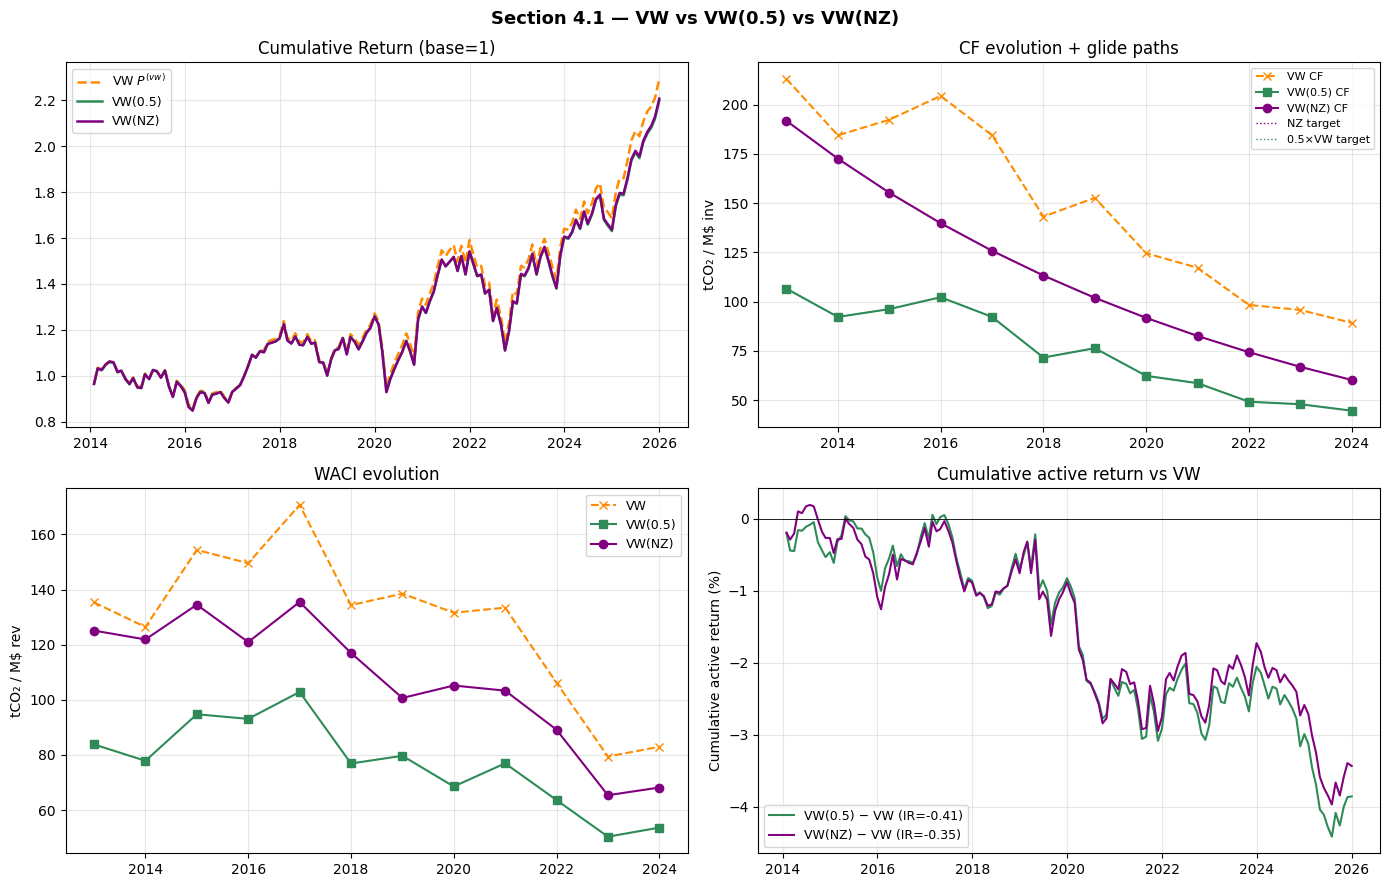

In [38]:

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Section 4.1 — VW vs VW(0.5) vs VW(NZ)", fontsize=13, fontweight="bold")
C_VW, C_VW5, C_NZ = "darkorange", "seagreen", "purple"

ax = axes[0, 0]
for rp, color, ls, lab in [
    (rp_vw, C_VW, "--", r"VW $P^{(vw)}$"),
    (rp_vw05, C_VW5, "-", r"VW(0.5)"),
    (rp_vwnz, C_NZ, "-", r"VW(NZ)"),
]:
    cum = (1 + rp.dropna()).cumprod()
    ax.plot(cum.index, cum.values, color=color, ls=ls, lw=1.8, label=lab)
ax.set_title("Cumulative Return (base=1)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(fmt)
ax.xaxis.set_major_locator(loc)

ax = axes[0, 1]
ax.plot(vw_carbon.index, vw_carbon["CF"], "x--", color=C_VW, label="VW CF")
ax.plot(vw05_carbon.index, vw05_carbon["CF"], "s-", color=C_VW5, label="VW(0.5) CF")
ax.plot(vwnz_carbon.index, vwnz_carbon["CF"], "o-", color=C_NZ, label="VW(NZ) CF")
ax.plot(cf_target_nz.index, cf_target_nz.values, ":", color=C_NZ, lw=1, label="NZ target")
ax.plot(cf_target_vw.index, cf_target_vw.values, ":", color=C_VW5, lw=1, label="0.5×VW target")
ax.set_title("CF evolution + glide paths")
ax.set_ylabel("tCO₂ / M$ inv")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(vw_carbon.index, vw_carbon["WACI"], "x--", color=C_VW, label="VW")
ax.plot(vw05_carbon.index, vw05_carbon["WACI"], "s-", color=C_VW5, label="VW(0.5)")
ax.plot(vwnz_carbon.index, vwnz_carbon["WACI"], "o-", color=C_NZ, label="VW(NZ)")
ax.set_title("WACI evolution")
ax.set_ylabel("tCO₂ / M$ rev")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ar05_cum = (1 + (rp_vw05 - rp_vw).dropna()).cumprod()
arnz_cum = (1 + (rp_vwnz - rp_vw).dropna()).cumprod()
ir05 = (rp_vw05 - rp_vw).mean() * 12 / ((rp_vw05 - rp_vw).std() * np.sqrt(12)) if (rp_vw05 - rp_vw).std() > 0 else np.nan
irnz = (rp_vwnz - rp_vw).mean() * 12 / ((rp_vwnz - rp_vw).std() * np.sqrt(12)) if (rp_vwnz - rp_vw).std() > 0 else np.nan
ax.plot(ar05_cum.index, (ar05_cum - 1) * 100, color=C_VW5, lw=1.5,
        label=f"VW(0.5) − VW (IR={ir05:+.2f})")
ax.plot(arnz_cum.index, (arnz_cum - 1) * 100, color=C_NZ, lw=1.5,
        label=f"VW(NZ) − VW (IR={irnz:+.2f})")
ax.axhline(0, color="k", lw=0.6)
ax.set_title("Cumulative active return vs VW")
ax.set_ylabel("Cumulative active return (%)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(fmt)
ax.xaxis.set_major_locator(loc)

plt.tight_layout()
plt.tight_layout()
plt.savefig(f"{OUT}SAAM_Part2_section41.pdf", dpi=150, bbox_inches="tight")
plt.show()

In [39]:
# ─── Section 4.2 — Cost of decarbonisation vs VW benchmark ────────────────────
# The cumulative-return comparison lives in §4.1 (cell 86). Here we quantify the
# *cost* of imposing carbon constraints in standard active-risk terms.

def cost_vs_bench(rp, rb, label):
    a = (rp - rb).dropna()
    ann_active = a.mean() * 12 * 100                              # in %
    te         = a.std(ddof=1) * np.sqrt(12) * 100                # in %
    ir         = ann_active / te if te > 0 else np.nan
    t_stat     = a.mean() / (a.std(ddof=1) / np.sqrt(len(a)))      # naive (no NW)
    cum_gap    = ((1 + rp).prod() / (1 + rb.loc[a.index]).prod() - 1) * 100
    return {"Portfolio": label,
            "Ann. Active Ret. (%)":      ann_active,
            "Tracking Error (%)":        te,
            "Information Ratio":         ir,
            "t-stat (active, naive)":    t_stat,
            "Final wealth gap vs VW (%)": cum_gap,
            "N months":                  int(len(a))}

cost_tbl = pd.DataFrame([
    cost_vs_bench(rp_vw05, rp_vw, "P^(vw)_oos(0.5)"),
    cost_vs_bench(rp_vwnz, rp_vw, "P^(vw)_oos(NZ)"),
]).set_index("Portfolio")

display(cost_tbl.style
        .set_caption("Section 4.2 — Cost of decarbonisation (vs VW benchmark)")
        .format({"Ann. Active Ret. (%)": "{:+.2f}",
                 "Tracking Error (%)":   "{:.2f}",
                 "Information Ratio":    "{:+.3f}",
                 "t-stat (active, naive)": "{:+.2f}",
                 "Final wealth gap vs VW (%)": "{:+.2f}",
                 "N months": "{:d}"})
        .set_table_styles([{"selector":"caption",
                            "props":[("font-weight","bold"),("font-size","13px")]}]))

# ─── Verification ─────────────────────────────────────────────────────────────
# (V1) Wealth-gap reconciles with direct cumprod ratio.
for rp, lab in [(rp_vw05, "VW(0.5)"), (rp_vwnz, "VW(NZ)")]:
    idx = rp.dropna().index
    gap_direct = ((1 + rp.loc[idx]).prod() / (1 + rp_vw.loc[idx]).prod() - 1) * 100
    gap_table  = cost_tbl.loc[f"P^(vw)_oos({'0.5' if 'VW(0.5)' in lab else 'NZ'})",
                              "Final wealth gap vs VW (%)"]
    print(f"V1 {lab:7s}: direct={gap_direct:+.4f}%  table={gap_table:+.4f}%  "
          f"-> {np.isclose(gap_direct, gap_table)}")

# (V2) Active return ≈ geometric-return spread from stats_nz (within rounding).
geom_vw   = stats_nz.loc["P^(vw)",           "Ann. Return Geom. (%)"]
geom_vw05 = stats_nz.loc["P^(vw)_oos(0.5)",  "Ann. Return Geom. (%)"]
geom_vwnz = stats_nz.loc["P^(vw)_oos(NZ)",   "Ann. Return Geom. (%)"]
print(f"V2 Geom-return spreads: "
      f"VW(0.5)−VW={geom_vw05-geom_vw:+.2f}% | "
      f"VW(NZ)−VW={geom_vwnz-geom_vw:+.2f}%   "
      f"(should be close to arithmetic active return, but not identical: "
      f"geometric ≠ arithmetic when vols differ)")

# (V3) The NZ glide path is binding: end-2024 CF should be near (1-θ)^12 × CF_2013.
cf_end   = vwnz_carbon["CF"].iloc[-1]
cf_naive = (1 - THETA) ** (2024 - 2013 + 1) * CF_VW_2013
print(f"V3 NZ end-2024: realized CF={cf_end:.2f}  raw glide-path target={cf_naive:.2f}  "
      f"reduction vs 2013 = {(1 - cf_end / CF_VW_2013) * 100:.1f}% "
      f"(theoretical = {(1 - (1-THETA)**12) * 100:.1f}%)")

,Ann. Active Ret. (%),Tracking Error (%),Information Ratio,"t-stat (active, naive)",Final wealth gap vs VW (%),N months
Portfolio,,,,,,
P^(vw)_oos(0.5),-0.32,0.80,-0.407,-1.41,-4.12,144
P^(vw)_oos(NZ),-0.29,0.82,-0.353,-1.22,-3.74,144


V1 VW(0.5): direct=-4.1194%  table=-4.1194%  -> True
V1 VW(NZ) : direct=-3.7413%  table=-3.7413%  -> True
V2 Geom-return spreads: VW(0.5)−VW=-0.37% | VW(NZ)−VW=-0.34%   (should be close to arithmetic active return, but not identical: geometric ≠ arithmetic when vols differ)
V3 NZ end-2024: realized CF=60.17  raw glide-path target=60.17  reduction vs 2013 = 71.8% (theoretical = 71.8%)
